**Predicting Loan Approval Decisions Using Machine Learning Classification Models**

- Overview

This project focuses on predicting loan approval status using machine learning techniques. The dataset contains applicant demographic, financial, employment, and credit-related information that can help determine whether a loan application is likely to be approved.

The objective is to build an intelligent classification model capable of assisting financial institutions in making faster, more consistent, and data-driven lending decisions.

In [4]:
# %pip install -q -U kagglehub

#### **Requirement Gathering, Data Source**

In [5]:
import os
import kagglehub
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

c:\Users\AYO_AYO\Desktop\Machine-Learning-Bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
# Download latest version
path = kagglehub.dataset_download("muhammadmusharraf444/loan-approval-dataset")
source_path = path
destination_path = os.getcwd()

# Copy dataset from source directory to destination directory
source_path = path
destination_path = os.getcwd()

shutil.copytree(source_path, destination_path, dirs_exist_ok = True)

'c:\\Users\\AYO_AYO\\Desktop\\Machine-Learning-Bootcamp'

In [7]:
source_path

'C:\\Users\\AYO_AYO\\.cache\\kagglehub\\datasets\\muhammadmusharraf444\\loan-approval-dataset\\versions\\1'

In [35]:
loan_df = pd.read_csv("./loan_data_new.csv")
loan_df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


#### **Dataset Overview**

In [36]:
print(loan_df.shape)
print(loan_df.columns.to_list())
print(loan_df.isna().sum())
print(loan_df.info())

(45000, 14)
['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status']
Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null

In [37]:
print(f"{loan_df.duplicated().sum()} duplicate/s was found in this dataset")

0 duplicate/s was found in this dataset


#### **Cleaning and Standardization**

In [40]:
loan_df = loan_df.rename(columns={"home_onwership": "home_ownership"})

loan_df.columns = loan_df.columns.str.replace(" ", "_").str.lower()

columns_to_lower = ["loan_intent", "home_ownership"]
loan_df[columns_to_lower] = loan_df[columns_to_lower].apply(lambda x: x.str.lower())

In [ ]:
# Assuming your target column name is 'loan_status'
# loan_df['loan_status'] = loan_df['loan_status'].map({"Yes": 1, "No": 0})

In [41]:
applicant_info = loan_df.columns[:4]
financial_info = loan_df.columns[4:6]
credit_info = loan_df.columns[6:]

target_variable = loan_df.iloc[:, -1]

numerical_cols = loan_df.select_dtypes([np.number]).columns.to_list()
categorical_cols = [x for x in loan_df.columns if x not in numerical_cols]

#### **Exploratory Data Analysis**

In [42]:
loan_approved_percentage = round(loan_df['loan_status'].value_counts(normalize=True), 3).mul(100)
print(loan_approved_percentage)

# Highly imbalanced dataset, 78% of loan request were rejected whilst only 22% were accepted, since the model is right 78% of the time, it'll treat others as same (reject)

loan_status
0    77.8
1    22.2
Name: proportion, dtype: float64


In [43]:
loan_df.columns

Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')

In [ ]:
salary_threshold = loan_df["person_income"].mean()
print(f"Salary threshold: {round((salary_threshold),2)}")

Salary threshold: 80319.05


In [71]:
# Do applicants with higher incomes get approved more often?

higher_income_group = loan_df[loan_df["person_income"] >= salary_threshold]
lower_income_group = loan_df[loan_df["person_income"] < salary_threshold]

# 2. Extract the exact approval rates
high_income_approval = (higher_income_group["loan_status"] == 1).mean() * 100
low_income_approval = (lower_income_group["loan_status"] == 1).mean() * 100

# Loan approval differences
print(f"High income loan approval rate: {round(high_income_approval, 2)}%")
print(f"Low income loan approval rate: {round(low_income_approval, 2)}%")

High income loan approval rate: 11.56%
Low income loan approval rate: 28.27%


In [86]:
# Does education level affect approval rates?

education_approval_rate = loan_df.groupby(loan_df["education"])["loan_status"].mean().mul(100).sort_values(ascending=False)
print(round(education_approval_rate, 2))

education
Doctorate      22.87
Bachelor       22.52
High School    22.31
Associate      22.03
Master         21.76
Name: loan_status, dtype: float64


In [ ]:
# Does self-employment status influence approval?
education_approval_rate = loan_df.groupby(loan_df["education"])[
    "loan_status"].mean().mul(100).sort_values(ascending=False)
print(round(education_approval_rate, 2))

$Visualization$

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

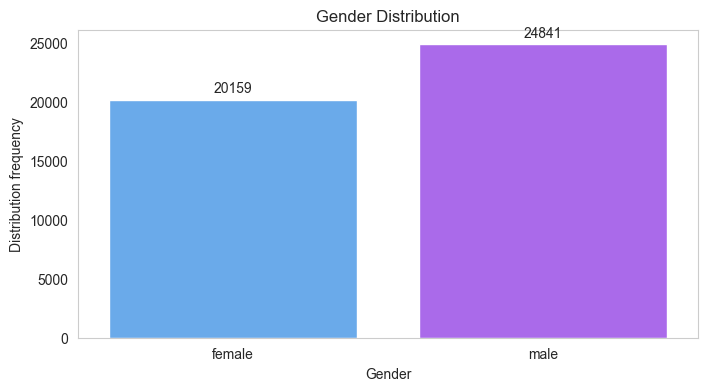

In [ ]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x=loan_df["gender"], palette="cool")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
    
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Distribution frequency")
plt.grid(False)
plt.show()

35000


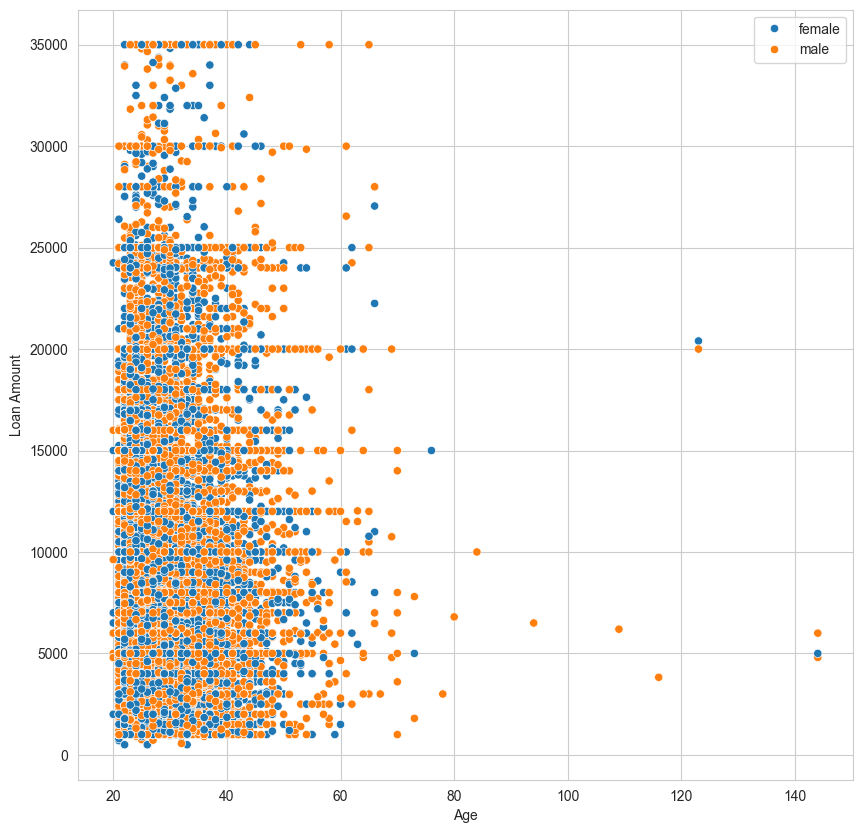

In [ ]:
print(loan_df["loan_amount"].max())

Q1 = loan_df["age"].quantile(.25)
Q3 = loan_df["age"].quantile(.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

normal = loan_df[(loan_df['age'] >= lower_bound) & (loan_df['age'] <= upper_bound)]
outliers = loan_df[(loan_df['age'] < lower_bound) | (loan_df['age'] > upper_bound)]

plt.figure(figsize=(10,10))
sns.scatterplot(x = loan_df["age"], y=loan_df["loan_amount"], hue=loan_df["gender"])
# plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')
# plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.xlabel("Age")
plt.ylabel("Loan Amount")
plt.legend()
plt.show()

<Figure size 1000x400 with 0 Axes>

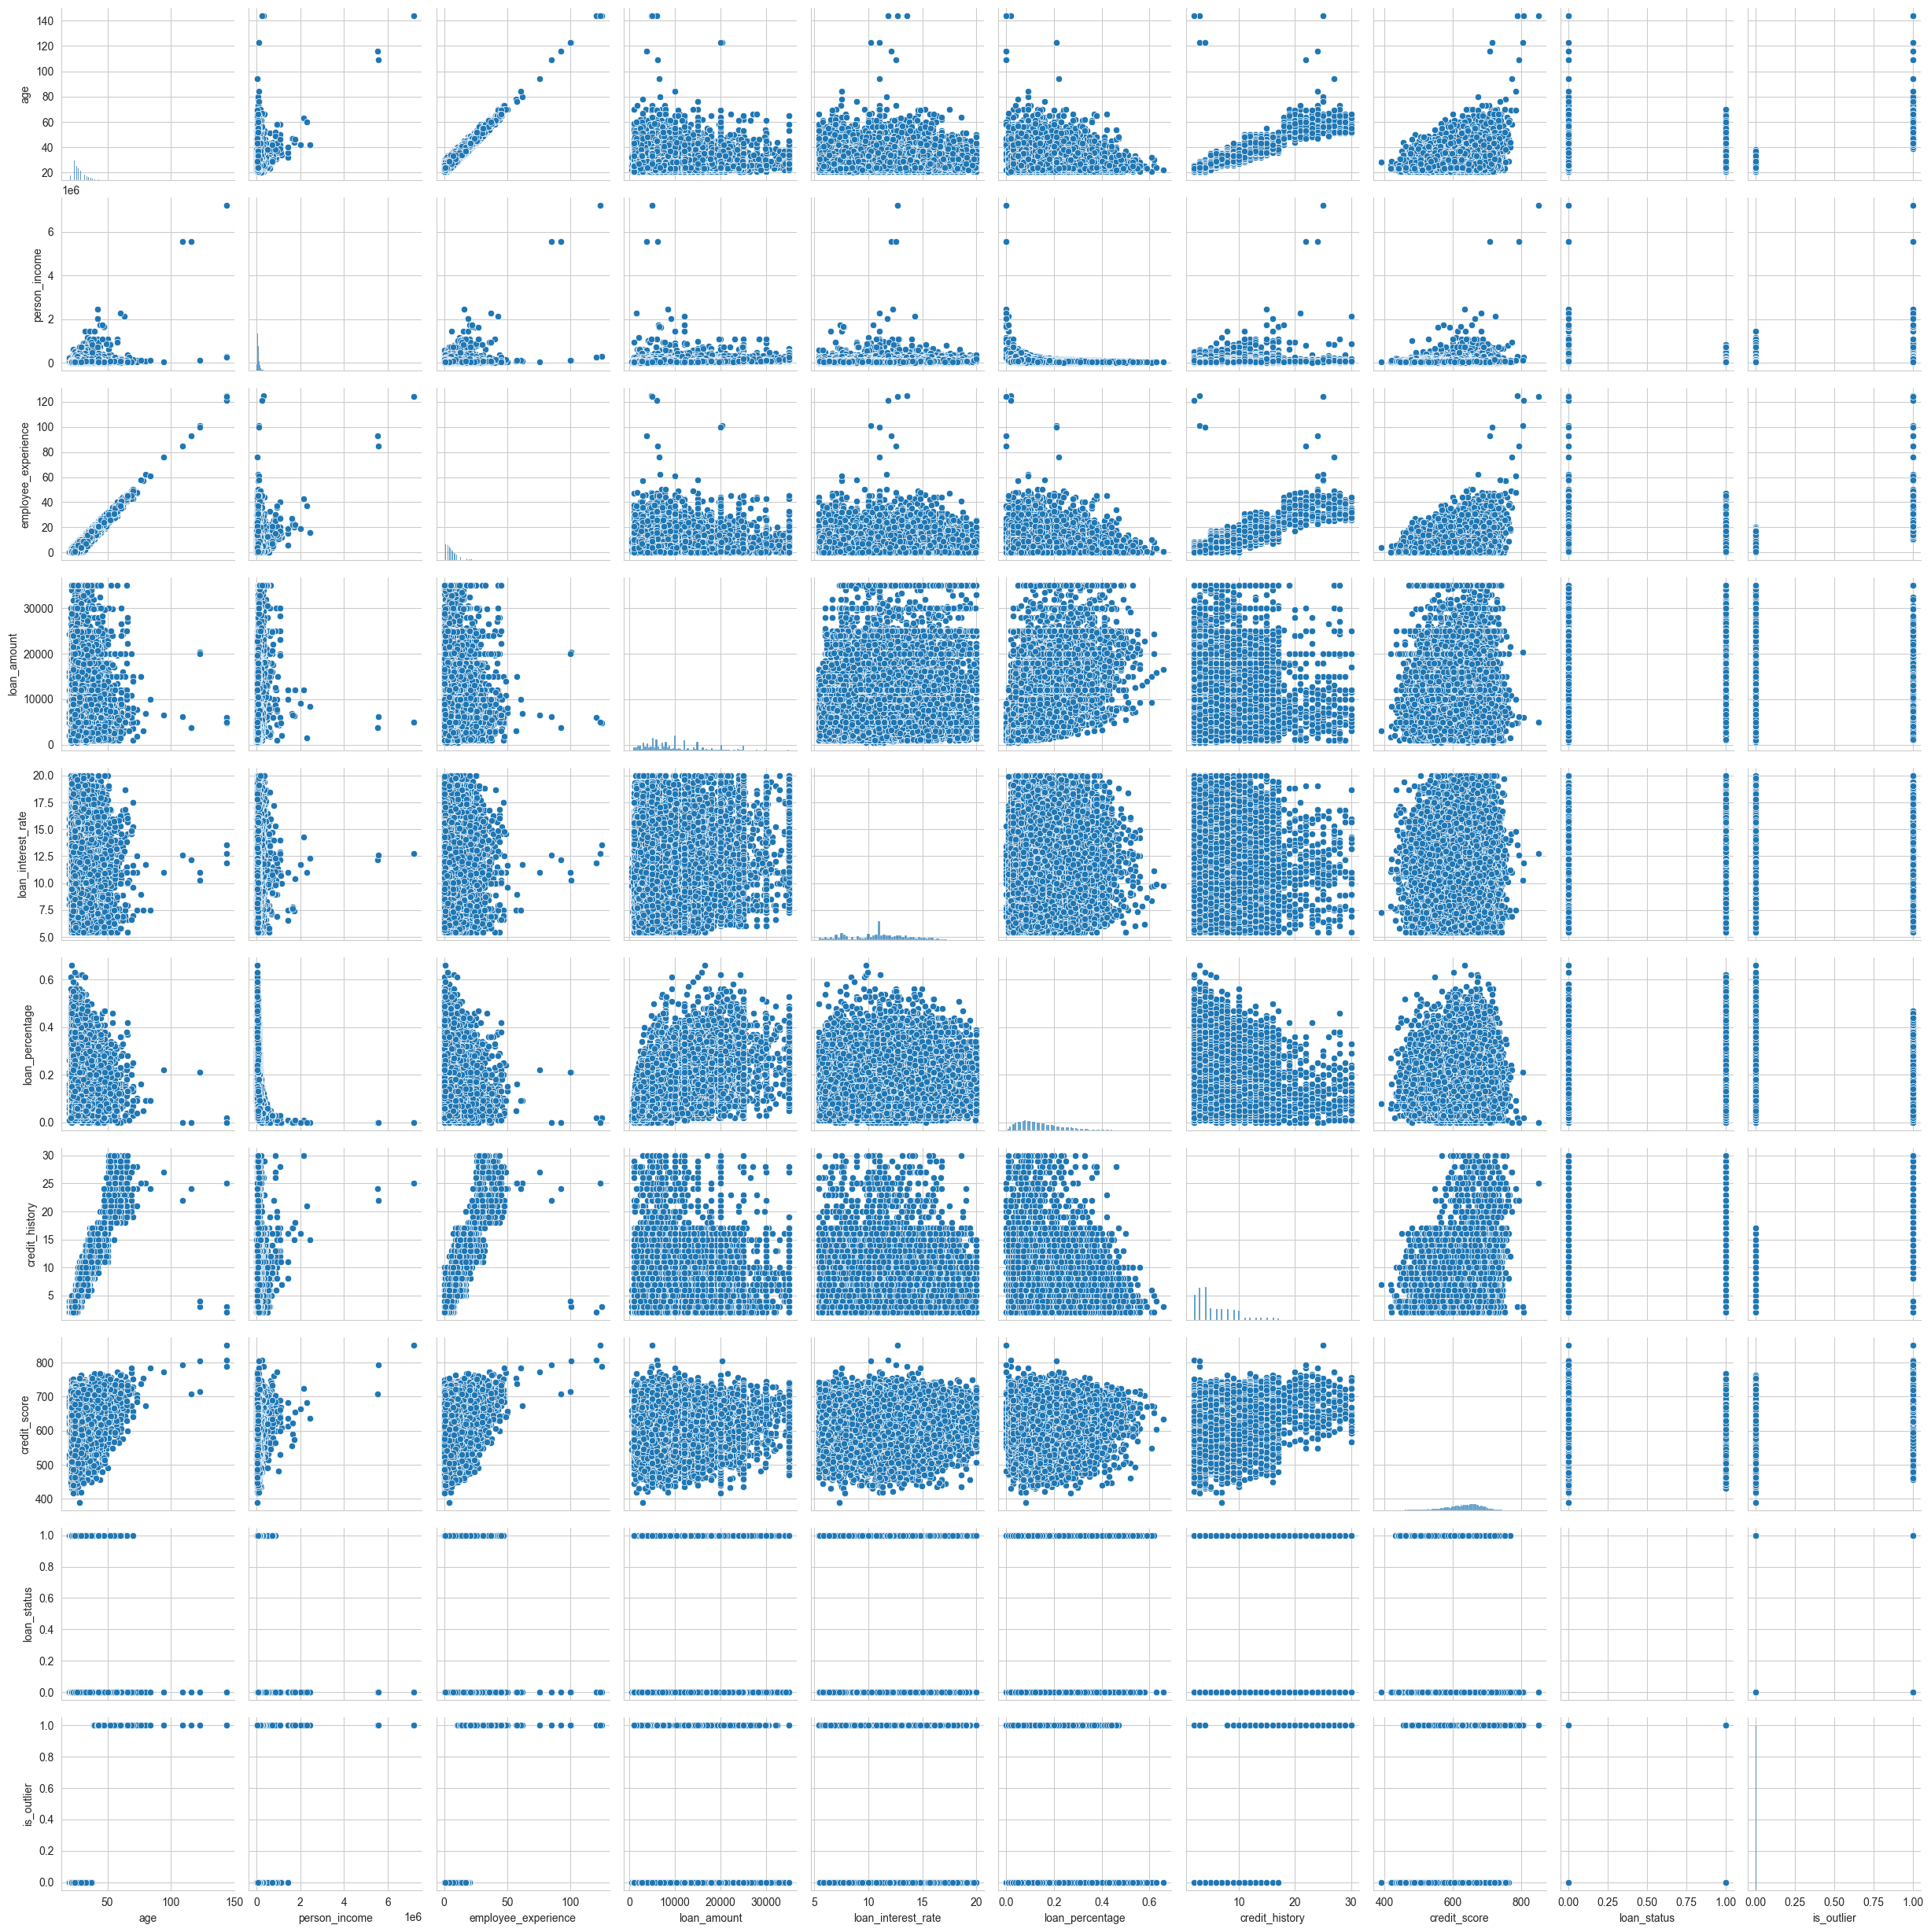